In [1]:
import os
# Set environment variables to avoid deadlocks with dataloaders
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# Set this to the GPU you want to use
os.environ["CUDA_VISIBLE_DEVICES"] = "2" 
import torch
import torch.nn as nn
import numpy as np
import json
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR100, Food101, Flowers102, DTD, EuroSAT, STL10, FGVCAircraft, MNIST, Country211
from torchvision import transforms
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from transformers import CLIPModel, CLIPProcessor, GPT2LMHeadModel
from peft import PeftModel
import timm # For Frozen's ResNet

In [2]:
# --- CONFIGURATION ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_ROOT = os.path.expanduser("~/.cache")
BATCH_SIZE = 64

# --- UPDATE THESE PATHS TO MATCH YOUR FILES ---
CLIP_MODEL_ID = "openai/clip-vit-base-patch32"
LORA_ADAPTER_PATH = "clip_lora_checkpoints/epoch-1" # Path to your saved LoRA
FROZEN_CHECKPOINT = "frozen_checkpoints/frozen_checkpoint_epoch1.pt"

print(f"Running comparison on {DEVICE}")

Running comparison on cuda


In [3]:
class CLIPWrapper(nn.Module):
    def __init__(self, base_name, adapter_path=None):
        super().__init__()
        self.base = CLIPModel.from_pretrained(base_name).to(DEVICE)
        self.processor = CLIPProcessor.from_pretrained(base_name)
        
        if adapter_path and os.path.exists(adapter_path):
            print(f"Loading LoRA Adapter from: {adapter_path}")
            self.model = PeftModel.from_pretrained(self.base, adapter_path)
            self.name = "LoRA CLIP (CC Trained)"
        else:
            print("Loading Standard CLIP")
            self.model = self.base
            self.name = "Standard CLIP"
        self.model.eval()

    def get_features(self, images):
        with torch.no_grad():
            # CLIP expects pixel_values
            features = self.model.get_image_features(pixel_values=images)
            # Normalize features
            return features / features.norm(dim=-1, keepdim=True)

class FrozenWrapper(nn.Module): # <--- Added inheritance here
    def __init__(self, checkpoint_path):
        super().__init__() # <--- Added super().__init__()
        print(f"Loading Frozen Model from: {checkpoint_path}")
        self.name = "Frozen (ResNet50)"
        
        # 1. Re-instantiate the Frozen Architecture structure
        self.backbone = timm.create_model("resnet50", pretrained=False, num_classes=0, global_pool='')
        self.pool = torch.nn.AdaptiveAvgPool2d(1)
        self.projection = torch.nn.Linear(2048, 2 * 1280) 
        
        # 2. Load Weights
        if os.path.exists(checkpoint_path):
            ckpt = torch.load(checkpoint_path, map_location=DEVICE)
            state_dict = ckpt.get('vision_encoder_state_dict', ckpt)
            
            # Filter keys
            backbone_specific = {k.replace('backbone.', ''): v for k, v in state_dict.items() if 'backbone' in k}
            proj_specific = {k.replace('projection.', ''): v for k, v in state_dict.items() if 'projection' in k}
            
            # Load with strict=False to ignore minor mismatches
            self.backbone.load_state_dict(backbone_specific, strict=False)
            self.projection.load_state_dict(proj_specific, strict=False)
        else:
            print("Warning: Frozen checkpoint not found. Using random weights.")

        # Now these work because we inherit from nn.Module
        self.to(DEVICE)
        self.eval()

    def get_features(self, images):
        with torch.no_grad():
            # Forward pass through ResNet
            x = self.backbone(images)
            x = self.pool(x).flatten(1)
            prefix = self.projection(x) 
            
            # Flatten (Batch, 2, 1280) -> (Batch, 2560)
            features = prefix.view(prefix.size(0), -1)
            
            # Normalize
            return features / features.norm(dim=-1, keepdim=True)

In [4]:
def get_features_and_labels(dataset, model_wrapper, processor):
    """
    Extracts features for the entire dataset using the specific model.
    """
    # Define standard transform
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Custom dataset wrapper to apply transform on the fly
    class EvalDataset(torch.utils.data.Dataset):
        def __init__(self, ds): self.ds = ds
        def __len__(self): return len(self.ds)
        def __getitem__(self, i):
            img, lbl = self.ds[i] if len(self.ds[i]) == 2 else self.ds[i][:2]
            return transform(img.convert("RGB")), int(lbl)

    loader = DataLoader(EvalDataset(dataset), batch_size=BATCH_SIZE, num_workers=4, shuffle=False)
    
    all_feats = []
    all_lbls = []
    
    print(f"[{model_wrapper.name}] Extracting features...")
    for imgs, lbls in tqdm(loader):
        imgs = imgs.to(DEVICE)
        feats = model_wrapper.get_features(imgs)
        all_feats.append(feats.cpu())
        all_lbls.append(lbls)
    
    return torch.cat(all_feats).numpy(), torch.cat(all_lbls).numpy()

def run_linear_probe(train_ds, test_ds, model_wrapper):
    # 1. Extract
    X_train, y_train = get_features_and_labels(train_ds, model_wrapper, None)
    X_test, y_test = get_features_and_labels(test_ds, model_wrapper, None)
    
    # 2. Train Linear Classifier (Logistic Regression)
    # C=1.0 is standard for Linear Probing in CLIP papers
    clf = LogisticRegression(C=1.0, max_iter=1000, n_jobs=-1)
    print(f"[{model_wrapper.name}] Training Classifier...")
    clf.fit(X_train, y_train)
    
    # 3. Score
    acc = clf.score(X_test, y_test) * 100.0
    print(f"[{model_wrapper.name}] Test Accuracy: {acc:.2f}%")
    return acc

Loading CIFAR100...
Files already downloaded and verified
Files already downloaded and verified
Loading Standard CLIP
Loading LoRA Adapter from: clip_lora_checkpoints/epoch-1
Loading Frozen Model from: frozen_checkpoints/frozen_checkpoint_epoch1.pt


/tmp/ipykernel_46535/744955580.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=DEVICE)



--- Benchmarking Standard CLIP ---
[Standard CLIP] Extracting features...


100%|██████████| 782/782 [00:59<00:00, 13.08it/s]


[Standard CLIP] Extracting features...


...

[LoRA CLIP (CC Trained)] Training Classifier...
[LoRA CLIP (CC Trained)] Test Accuracy: 73.55%

--- Benchmarking Frozen (ResNet50) ---
[Frozen (ResNet50)] Extracting features...


100%|██████████| 782/782 [00:53<00:00, 14.51it/s]


[Frozen (ResNet50)] Extracting features...


100%|██████████| 157/157 [00:12<00:00, 12.75it/s]


[Frozen (ResNet50)] Training Classifier...
[Frozen (ResNet50)] Test Accuracy: 47.26%


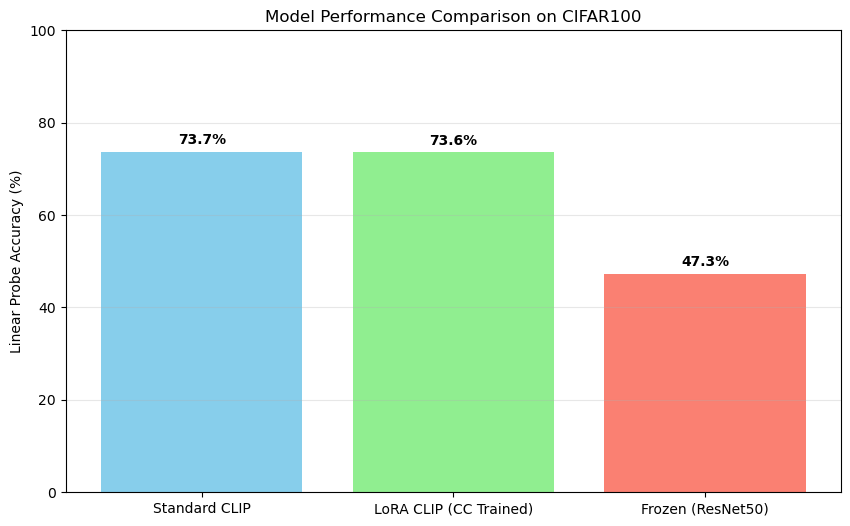

: 

In [5]:
# 1. Select Dataset (Start with CIFAR100 for speed)
print("Loading CIFAR100...")
train_set = CIFAR100(root=DATA_ROOT, train=True, download=True)
test_set = CIFAR100(root=DATA_ROOT, train=False, download=True)

# 2. Initialize Models
models = [
    CLIPWrapper(CLIP_MODEL_ID),                       # Standard
    CLIPWrapper(CLIP_MODEL_ID, LORA_ADAPTER_PATH),    # LoRA
    FrozenWrapper(FROZEN_CHECKPOINT)                  # Frozen
]

# 3. Run Comparison
results = {}
for model in models:
    print(f"\n--- Benchmarking {model.name} ---")
    acc = run_linear_probe(train_set, test_set, model)
    results[model.name] = acc

# 4. Visualize Results
plt.figure(figsize=(10, 6))
bars = plt.bar(results.keys(), results.values(), color=['skyblue', 'lightgreen', 'salmon'])

plt.ylabel("Linear Probe Accuracy (%)")
plt.title(f"Model Performance Comparison on CIFAR100")
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

# Add numbers on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.savefig("final_comparison_chart.png")
plt.show()